# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Setup + imports

In [25]:
import os
import json
import joblib
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

RANDOM_STATE = 42


os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

con = duckdb.connect()

HF_TOKEN = userdata.get("HF_TOKEN")

con.execute("DROP SECRET IF EXISTS hf_secret")
con.execute(f"""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
)
""")

MODEL_PATH = "/content/ml08_logistic_regression_model.pkl"
METADATA_PATH = "/content/ml08_model_metadata.json"

model = joblib.load(MODEL_PATH)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print("Setup complete.")
print("Model loaded:", type(model).__name__)
print("Metadata loaded:", bool(metadata))
print("Output directory ready:", os.path.exists("work/outputs"))

Setup complete.
Model loaded: Pipeline
Metadata loaded: True
Output directory ready: True


In [26]:
# Rebuild the data needed for the action queue
# Historical feature window: April + May 2026
feature_data = con.execute("""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_90d,
        SUM(gsc_clicks) AS clicks_90d,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_sum_position) / SUM(gsc_impressions)
            ELSE NULL
        END AS avg_position_90d
    FROM read_parquet([
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/data_0.parquet',
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-05/data_0.parquet'
    ])
    GROUP BY client_hash_id, content_hash_id
""").df()

# Same population rule used in ML-08
playbook_df = feature_data[
    feature_data["impressions_90d"] >= 100
].copy()

# Historical CTR
playbook_df["ctr_90d"] = np.where(
    playbook_df["impressions_90d"] > 0,
    playbook_df["clicks_90d"] / playbook_df["impressions_90d"],
    0
)

MODEL_FEATURES = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "ctr_90d"
]

# Score using the saved ML-08 model
playbook_df["model_score"] = model.predict_proba(
    playbook_df[MODEL_FEATURES]
)[:, 1]

print("Feature rows:", len(feature_data))
print("Scored rows:", len(playbook_df))
print("Clients:", playbook_df["client_hash_id"].nunique())
print("Features:", MODEL_FEATURES)

print("\nTop 10 model scores:")
print(
    playbook_df[
        ["content_hash_id", "client_hash_id", "model_score"]
    ]
    .sort_values("model_score", ascending=False)
    .head(10)
    .to_string(index=False)
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature rows: 389153
Scored rows: 136830
Clients: 53
Features: ['impressions_90d', 'clicks_90d', 'avg_position_90d', 'ctr_90d']

Top 10 model scores:
         content_hash_id          client_hash_id  model_score
content_af6dd069f6d917eb client_62f4a7e64f5e0096     0.724612
content_f78d8bf1fd3060ce client_a80fca3f171ed1de     0.724521
content_541c9e8400addee2 client_73cda7b4e4f265ea     0.724134
content_4c893930c1ef01b9 client_a80fca3f171ed1de     0.724110
content_d9fd8d0dbbc504ce client_73cda7b4e4f265ea     0.723954
content_5d84ff5db281fd29 client_62f4a7e64f5e0096     0.723896
content_0ef15cf0a68603a9 client_e547b89c05043229     0.723633
content_260ae1ff822ea934 client_73cda7b4e4f265ea     0.723538
content_d94ca5b6391b12b3 client_23a62021009f63c4     0.723399
content_01f9a4eabd8cf53b client_73cda7b4e4f265ea     0.723326


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue ranks content opportunities using the saved ML-08 model score and simple human-readable rules. Each flagged page receives an archetype, recommended action, reason code, and cost/value tier so that the ranking can support human review rather than act as an automatic decision.

In [27]:
#Build the ranked action queue

content_metadata = con.execute("""
    SELECT
        content_hash_id,
        content_updated_date
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
    )
""").df()

playbook_df = playbook_df.merge(
    content_metadata,
    on="content_hash_id",
    how="left"
)

playbook_df["days_since_last_update"] = (
    pd.Timestamp("2026-06-30")
    - pd.to_datetime(playbook_df["content_updated_date"])
).dt.days

# Practical thresholds
HIGH_RISK_THRESHOLD = 0.60
HIGH_VALUE_THRESHOLD = playbook_df["impressions_90d"].quantile(0.75)
STALE_DAYS = 180


def assign_action(row):
    if row["model_score"] < HIGH_RISK_THRESHOLD:
        return (
            "Stable",
            "No action needed",
            "STB-01",
            "Lower model-ranked decline risk",
            "None"
        )

    if row["impressions_90d"] >= HIGH_VALUE_THRESHOLD:
        return (
            "Priority Refresh",
            "Review and refresh content",
            "REF-01",
            "Higher model-ranked decline risk with relatively high historical traffic",
            "High cost / high value"
        )

    if 10 <= row["avg_position_90d"] <= 20:
        return (
            "Position Push",
            "Review on-page signals and internal links",
            "REF-02",
            "Higher model-ranked decline risk with historical position near page one",
            "Low cost / medium value"
        )

    if row["days_since_last_update"] >= STALE_DAYS:
        return (
            "Stale Watch",
            "Queue for content audit",
            "REF-03",
            "Higher model-ranked decline risk and no recent update",
            "Medium cost / medium value"
        )

    return (
        "Low-Value Monitor",
        "Monitor and recheck next cycle",
        "REF-04",
        "Higher model-ranked decline risk but relatively low historical traffic",
        "Low cost / low value"
    )


playbook_df[
    [
        "archetype",
        "recommended_action",
        "reason_code",
        "reason_text",
        "cost_value_tier"
    ]
] = playbook_df.apply(
    lambda row: pd.Series(assign_action(row)),
    axis=1
)

ranked_queue = (
    playbook_df[playbook_df["archetype"] != "Stable"]
    [
        [
            "content_hash_id",
            "client_hash_id",
            "model_score",
            "archetype",
            "recommended_action",
            "reason_code",
            "reason_text",
            "cost_value_tier",
            "impressions_90d",
            "avg_position_90d",
            "days_since_last_update"
        ]
    ]
    .sort_values("model_score", ascending=False)
    .reset_index(drop=True)
)

print("Archetype counts:")
print(playbook_df["archetype"].value_counts().to_string())

print("\nRanked queue size:", len(ranked_queue))

print("\nTop 10 ranked actions:")
print(ranked_queue.head(10).to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Archetype counts:
archetype
Stable               59390
Low-Value Monitor    42310
Position Push        20207
Priority Refresh     14842
Stale Watch             81

Ranked queue size: 77440

Top 10 ranked actions:
         content_hash_id          client_hash_id  model_score         archetype             recommended_action reason_code                                                            reason_text      cost_value_tier  impressions_90d  avg_position_90d  days_since_last_update
content_af6dd069f6d917eb client_62f4a7e64f5e0096     0.724612 Low-Value Monitor Monitor and recheck next cycle      REF-04 Higher model-ranked decline risk but relatively low historical traffic Low cost / low value            205.0          0.009756                      -3
content_f78d8bf1fd3060ce client_a80fca3f171ed1de     0.724521 Low-Value Monitor Monitor and recheck next cycle      REF-04 Higher model-ranked decline risk but relatively low historical traffic Low cost / low value            129.0        

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

The playbook is intended for a content editor or SEO lead to use as decision-support when prioritizing pages for review. It ranks pages using the saved ML-08 model score and adds simple action rules to make the ranking easier to interpret.

The queue does not publish, rewrite, remove, or otherwise change content automatically.

The ML-08 Precision@10 result of 0.80 comes only from the 11 held-out clients used for evaluation. The ML-10 scoring queue is generated across the available scoring population and should not be interpreted as having 0.80 Precision@10.

Limits:

- The ML-08 model was evaluated on 11 held-out clients, so these results are not evidence that the ranking will generalize to every client or industry.
- The model uses historical impressions, clicks, average position, and CTR. It does not observe content quality, search intent, seasonality, competitor activity, algorithm updates, or business priorities.
- The action rules are practical heuristics added after scoring; they were not separately validated as causal interventions.
- The model score is a ranking signal, not a guarantee that a page will decline or that a recommended refresh will improve traffic.
- The queue should therefore be treated as directional decision-support requiring human review.

In [28]:
print("ML-08 held-out evaluation:")
print("Test clients: 11")
print("Test rows: 45,599")
print("Precision@10: 0.80")
print("Precision@20: 0.70")
print("Precision@50: 0.68")
print("Precision@100: 0.66")

print("\nCurrent ML-10 queue:")
print("Scored pages:", len(playbook_df))
print("Flagged pages:", len(ranked_queue))
print("Stable pages:", (playbook_df["archetype"] == "Stable").sum())

ML-08 held-out evaluation:
Test clients: 11
Test rows: 45,599
Precision@10: 0.80
Precision@20: 0.70
Precision@50: 0.68
Precision@100: 0.66

Current ML-10 queue:
Scored pages: 136830
Flagged pages: 77440
Stable pages: 59390


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Every flagged page must be reviewed by a human before any content change is made. The reviewer should confirm that the page still exists, that the recommended action fits the page, and that current business or editorial context does not make the recommendation inappropriate.

The model cannot see recent campaigns, planned content changes, rebranding, search-intent changes, or content-quality issues, so the queue should not be treated as an automatic decision.

No-go cases:
- Do not automatically publish, rewrite, delete, or redirect any page.
- Do not act on pages updated very recently without human confirmation.
- Do not use the ranking alone for legal, medical, financial, or other sensitive-topic content.
- Do not act on pages affected by an active campaign or known business change without checking with the responsible owner.
- Pages with fewer than 100 historical impressions are outside the evaluated population and should not be treated as model-supported recommendations.

In [29]:
RECENT_UPDATE_DAYS = 30

recent_pages = ranked_queue[
    ranked_queue["days_since_last_update"].between(0, RECENT_UPDATE_DAYS - 1)
]

missing_update_dates = ranked_queue[
    ranked_queue["days_since_last_update"].isna()
]

print("Human-review checks:")
print("Flagged queue:", len(ranked_queue))
print("Recently updated pages requiring extra review:", len(recent_pages))
print("Missing update dates:", len(missing_update_dates))
print("Minimum historical impressions in queue:",
      ranked_queue["impressions_90d"].min())

Human-review checks:
Flagged queue: 77440
Recently updated pages requiring extra review: 21512
Missing update dates: 0
Minimum historical impressions in queue: 100.0


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The playbook should be checked regularly because the relationships learned from historical traffic may change over time.

The following triggers should be monitored:

- Retrain or investigate if Precision@10 on a new labeled evaluation falls below the ML-08 reference value of 0.80.
- Review the model if the observed declining rate changes substantially from the ML-08 reference rate of 58%.
- Review feature distributions if historical impressions, clicks, CTR, or average position show substantial drift from the training data.
- Review the action thresholds if the size or composition of the ranked queue changes substantially between cycles.
- Retrain on a rolling schedule when sufficient new labeled data becomes available, even if no single monitoring trigger fires.

These are monitoring rules, not guarantees that the model has failed. A trigger should lead to investigation, comparison with the baseline, and human review before replacing the model.

In [30]:
ML08_PRECISION_AT_10 = 0.80
ML08_DECLINING_RATE = 0.58


print("ML-08 monitoring references:")
print(f"Precision@10 reference: {ML08_PRECISION_AT_10:.2f}")
print(f"Declining-rate reference: {ML08_DECLINING_RATE:.1%}")

print("\nML-10 scoring population:")
print(f"Scored pages: {len(playbook_df):,}")
print(f"Flagged pages: {len(ranked_queue):,}")
print(
    "Flagged share:",
    f"{len(ranked_queue) / len(playbook_df):.1%}"
)

print("\nMonitoring note:")
print("A new labeled evaluation is required to measure Precision@10.")
print("The current ML-10 queue alone cannot measure future model accuracy.")

ML-08 monitoring references:
Precision@10 reference: 0.80
Declining-rate reference: 58.0%

ML-10 scoring population:
Scored pages: 136,830
Flagged pages: 77,440
Flagged share: 56.6%

Monitoring note:
A new labeled evaluation is required to measure Precision@10.
The current ML-10 queue alone cannot measure future model accuracy.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked action queue and summary metrics are exported to the required output directories.

The queue is regenerated from the saved ML-08 model and warehouse data. The metrics summarize the scoring population, action categories, and thresholds used in this playbook.

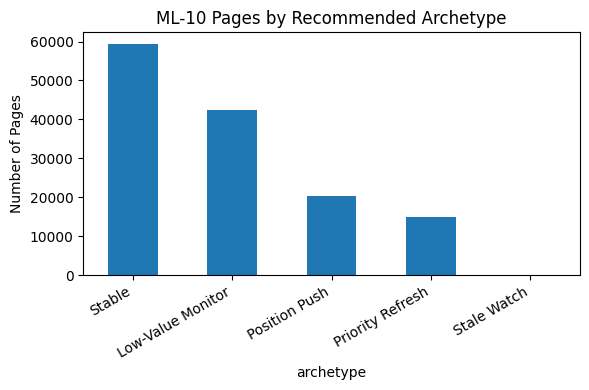

Exported files:
work/outputs/w07_ranked_action_queue.csv
work/outputs/w07_metrics.json
work/figures/w07_archetype_counts.png


In [31]:
import matplotlib.pyplot as plt
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Ranked action queue
queue_path = "work/outputs/w07_ranked_action_queue.csv"
ranked_queue.to_csv(queue_path, index=False)

# Metrics summary
metrics_summary = {
    "model_source": "ML-08 saved Logistic Regression pipeline",
    "scored_pages": int(len(playbook_df)),
    "flagged_pages": int(len(ranked_queue)),
    "stable_pages": int((playbook_df["archetype"] == "Stable").sum()),
    "flagged_share": float(len(ranked_queue) / len(playbook_df)),
    "ml08_precision_at_10": 0.80,
    "ml08_precision_at_20": 0.70,
    "ml08_precision_at_50": 0.68,
    "ml08_precision_at_100": 0.66,
    "ml08_declining_rate": 0.58,
    "high_risk_threshold": float(HIGH_RISK_THRESHOLD),
    "high_value_threshold_impressions_90d": float(HIGH_VALUE_THRESHOLD),
    "stale_days_threshold": int(STALE_DAYS),
    "recent_update_days": int(RECENT_UPDATE_DAYS),
    "archetype_counts": playbook_df["archetype"].value_counts().to_dict()
}

metrics_path = "work/outputs/w07_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

# Archetype figure
fig, ax = plt.subplots(figsize=(6, 4))

playbook_df["archetype"].value_counts().plot(
    kind="bar",
    ax=ax
)

ax.set_title("ML-10 Pages by Recommended Archetype")
ax.set_ylabel("Number of Pages")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

figure_path = "work/figures/w07_archetype_counts.png"
plt.savefig(figure_path, dpi=150)
plt.show()

print("Exported files:")
print(queue_path)
print(metrics_path)
print(figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.